In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
import json

with open('Agri_data.json', 'r') as file:
    data = json.load(file)

print(type(data))
print(data)

<class 'dict'>
{'created': 1627939168, 'updated': 1779008462, 'created_date': '2021-08-02T21:19:28Z', 'updated_date': '2026-05-17T09:01:02Z', 'active': '1', 'index_name': '9ef84268-d588-465a-a308-a864a43d0070', 'org': ['Ministry of Agriculture and Farmers Welfare', 'Department of Agriculture and Farmers Welfare'], 'org_type': 'Central', 'source': 'data.gov.in', 'title': 'Current Daily Price of Various Commodities from Various Markets (Mandi)', 'external_ws_url': '', 'visualizable': '1', 'field': [{'name': 'State', 'id': 'state', 'type': 'keyword'}, {'name': 'District', 'id': 'district', 'type': 'keyword'}, {'name': 'Market', 'id': 'market', 'type': 'keyword'}, {'name': 'Commodity', 'id': 'commodity', 'type': 'keyword'}, {'name': 'Variety', 'id': 'variety', 'type': 'keyword'}, {'name': 'Grade', 'id': 'grade', 'type': 'keyword'}, {'name': 'Arrival_Date', 'id': 'arrival_date', 'type': 'date'}, {'name': 'Min_x0020_Price', 'id': 'min_price', 'type': 'double'}, {'name': 'Max_x0020_Price', 'i

In [42]:
print(data.keys())

dict_keys(['created', 'updated', 'created_date', 'updated_date', 'active', 'index_name', 'org', 'org_type', 'source', 'title', 'external_ws_url', 'visualizable', 'field', 'external_ws', 'catalog_uuid', 'sector', 'target_bucket', 'desc', 'field_exposed', 'message', 'version', 'status', 'total', 'count', 'limit', 'offset', 'records'])


In [43]:


with open('Agri_data.json', 'r') as file:
    data = json.load(file)

df = pd.DataFrame(data['records'])

df.head()

,state,district,market,commodity,variety,grade,arrival_date,min_price,max_price,modal_price
0,Telangana,Mahbubnagar,Wanaparthy town APMC,Groundnut,Local,Local,17/05/2026,6025.0,8600.0,7929.0
1,Kerala,Ernakulam,Piravam APMC,Bhindi(Ladies Finger),Bhindi,Local,17/05/2026,5000.0,7000.0,6000.0
2,Uttar Pradesh,Etah,Aliganj APMC,Chicory(Chikori/Kasni),Other,FAQ,17/05/2026,3200.0,3200.0,3200.0
3,Kerala,Kannur,Thalasserry APMC,Tomato,Other,FAQ,17/05/2026,3300.0,4300.0,3700.0
4,Kerala,Kannur,Thalasserry APMC,Onion,1st Sort,FAQ,17/05/2026,1800.0,2500.0,2000.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   state         8406 non-null   object 
 1   district      8406 non-null   object 
 2   market        8406 non-null   object 
 3   commodity     8406 non-null   object 
 4   variety       8406 non-null   object 
 5   grade         8406 non-null   object 
 6   arrival_date  8406 non-null   object 
 7   min_price     8406 non-null   float64
 8   max_price     8406 non-null   float64
 9   modal_price   8406 non-null   float64
dtypes: float64(3), object(7)
memory usage: 656.8+ KB


In [45]:
df.describe()

,min_price,max_price,modal_price
count,8406.000000,8406.000000,8406.000000
mean,4836.955619,5429.387806,5133.949970
std,4655.451153,5099.610335,4859.000077
min,3.000000,6.000000,4.000000
25%,2500.000000,3000.000000,2750.000000
50%,3600.000000,4000.000000,3850.000000
75%,5000.000000,6000.000000,5500.000000
max,110000.000000,110000.000000,110000.000000


In [10]:
df.isnull().sum()

state           0
district        0
market          0
commodity       0
variety         0
grade           0
arrival_date    0
min_price       0
max_price       0
modal_price     0
dtype: int64

In [46]:
df.sample(2)

,state,district,market,commodity,variety,grade,arrival_date,min_price,max_price,modal_price
2427,Tamil Nadu,Thiruchirappalli,Manapparai(Uzhavar Sandhai ),Cabbage,Cabbage,Local,17/05/2026,3600.0,3600.0,3600.0
8385,Tamil Nadu,The Nilgiris,Gudalur(Uzhavar Sandhai ),Mint(Pudina),Mint(Pudina),Local,17/05/2026,4500.0,5000.0,4750.0


In [47]:
df['arrival_date']= pd.to_datetime(df['arrival_date'],dayfirst=True)

In [48]:
df.sample(2)

,state,district,market,commodity,variety,grade,arrival_date,min_price,max_price,modal_price
966,Tamil Nadu,Thirupur,Tiruppur (South) (Uzhavar Sandhai ),Thondekai,Thondekai,Local,2026-05-17,3000.0,4000.0,3500.0
8135,Tamil Nadu,Coimbatore,Singanallur(Uzhavar Sandhai ),Mousambi(Sweet Lime),Mousambi,Local,2026-05-17,7000.0,8000.0,7500.0


In [49]:
for i in range(0, len(df)):
    if (df['min_price'][i]+df['max_price'][i])/2!=df['modal_price'][i]:
        print(f"Row {i} has inconsistent price data.")
        break
    else:
        print("All rows have consistent price data.")

Row 0 has inconsistent price data.


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   state         8406 non-null   object        
 1   district      8406 non-null   object        
 2   market        8406 non-null   object        
 3   commodity     8406 non-null   object        
 4   variety       8406 non-null   object        
 5   grade         8406 non-null   object        
 6   arrival_date  8406 non-null   datetime64[ns]
 7   min_price     8406 non-null   float64       
 8   max_price     8406 non-null   float64       
 9   modal_price   8406 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 656.8+ KB


In [50]:
df['commodity'].nunique()

145

In [23]:
df['commodity'].unique()

array(['Groundnut', 'Bhindi(Ladies Finger)', 'Chicory(Chikori/Kasni)',
       'Tomato', 'Onion', 'Snakeguard', 'Banana', 'Lemon', 'Cowpea(Veg)',
       'Bitter gourd', 'Amaranthus', 'Ginger(Green)', 'Chili Red',
       'Green Gram(Moong)(Whole)', 'Peas(Dry)', 'Wheat', 'Rice', 'Potato',
       'Wood', 'Chikoos(Sapota)', 'Karbuja(Musk Melon)',
       'Cucumbar(Kheera)', 'Ridgeguard(Tori)', 'Carrot', 'Drumstick',
       'Little gourd(Kundru)', 'Papaya', 'Apple', 'Amla(Nelli Kai)',
       'Onion Green', 'Coriander(Leaves)', 'Methi(Leaves)', 'Beans',
       'Lime', 'Brinjal', 'Garlic', 'Green Chilli', 'Bottle gourd',
       'Banana - Green', 'Ashgourd', 'Capsicum', 'Tender Coconut',
       'Mint(Pudina)', 'Coconut', 'Yam(Ratalu)', 'Maize', 'Mustard',
       'Soyabean', 'Linseed', 'Kutki', 'Paddy(Common)', 'Mango',
       'Pumpkin', 'Thondekai', 'Sweet Corn ', 'Cabbage',
       'Mango(Raw-Ripe)', 'Colacasia', 'Grapes', 'Kulthi(Horse Gram)',
       'Green Avare(W)', 'Baby Corn', 'Cauliflower'

In [51]:
translations={
    'Pea Pod/Pea Cod/हरी मटर': 'Pea Pod/Pea Cod',
}

df['commodity'] = df['commodity'].replace(translations)

In [28]:
df['commodity'].unique()

array(['Groundnut', 'Bhindi(Ladies Finger)', 'Chicory(Chikori/Kasni)',
       'Tomato', 'Onion', 'Snakeguard', 'Banana', 'Lemon', 'Cowpea(Veg)',
       'Bitter gourd', 'Amaranthus', 'Ginger(Green)', 'Chili Red',
       'Green Gram(Moong)(Whole)', 'Peas(Dry)', 'Wheat', 'Rice', 'Potato',
       'Wood', 'Chikoos(Sapota)', 'Karbuja(Musk Melon)',
       'Cucumbar(Kheera)', 'Ridgeguard(Tori)', 'Carrot', 'Drumstick',
       'Little gourd(Kundru)', 'Papaya', 'Apple', 'Amla(Nelli Kai)',
       'Onion Green', 'Coriander(Leaves)', 'Methi(Leaves)', 'Beans',
       'Lime', 'Brinjal', 'Garlic', 'Green Chilli', 'Bottle gourd',
       'Banana - Green', 'Ashgourd', 'Capsicum', 'Tender Coconut',
       'Mint(Pudina)', 'Coconut', 'Yam(Ratalu)', 'Maize', 'Mustard',
       'Soyabean', 'Linseed', 'Kutki', 'Paddy(Common)', 'Mango',
       'Pumpkin', 'Thondekai', 'Sweet Corn ', 'Cabbage',
       'Mango(Raw-Ripe)', 'Colacasia', 'Grapes', 'Kulthi(Horse Gram)',
       'Green Avare(W)', 'Baby Corn', 'Cauliflower'

In [52]:
df['commodity'].nunique()

145

In [53]:
df['commodity'].value_counts()

commodity
Wheat                        263
Tomato                       237
Potato                       228
Onion                        225
Green Chilli                 217
                            ... 
Mustard Oil                    1
Sweet Saag                     1
Green Gram Dal(Moong Dal)      1
French Beans(Frasbean)         1
Ginger(Dry)                    1
Name: count, Length: 145, dtype: int64

In [54]:
counts = df['commodity'].value_counts()

rare_commodities = counts[counts <= 10].index

df['commodity'] = df['commodity'].replace(
    rare_commodities,
    'Other'
)

<Axes: ylabel='count'>

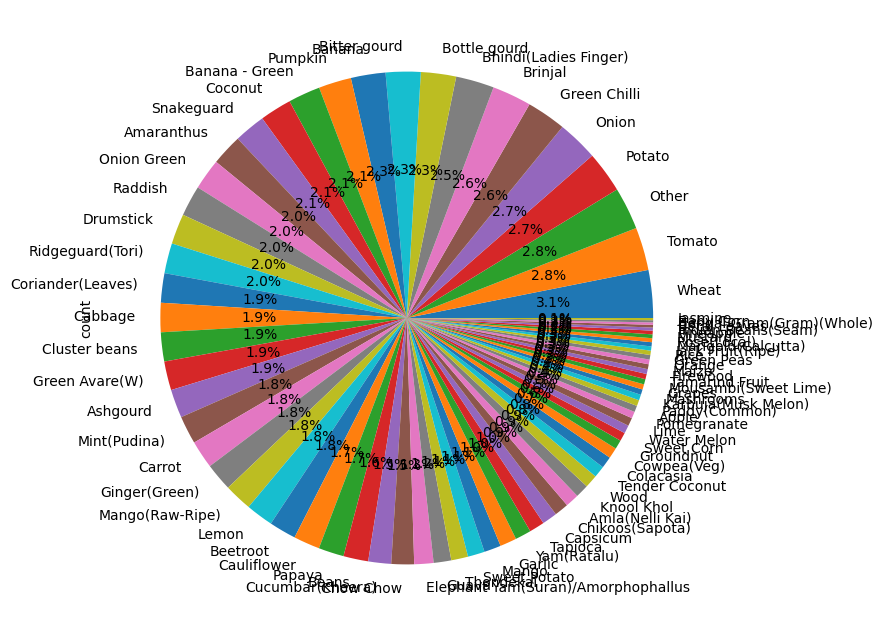

In [56]:
df['commodity'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))

In [83]:
df.sample(2)

,state,district,market,commodity,variety,grade,arrival_date,min_price,max_price,modal_price
1446,Tamil Nadu,Ranipet,Arcot(Uzhavar Sandhai ),Beetroot,Beetroot,Local,2026-05-17,4500.0,4500.0,4500.0
4243,Tamil Nadu,Chengalpattu,Chengalpet(Uzhavar Sandhai ),Beans,Beans (Whole),Local,2026-05-17,12000.0,13000.0,12500.0


In [76]:
df['state'].unique()

array(['Telangana', 'Kerala', 'Uttar Pradesh', 'Maharashtra', 'Tripura',
       'Tamil Nadu', 'Madhya Pradesh', 'Gujarat', 'Karnataka', 'Punjab',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Assam', 'Haryana',
       'Rajasthan', 'Chandigarh', 'NCT of Delhi', 'Himachal Pradesh',
       'Chattisgarh', 'Andhra Pradesh'], dtype=object)

In [71]:
count = sum(df['state'] == 'Rajasthan')

print(count)

33


In [68]:
print(count)

33


<Axes: xlabel='state'>

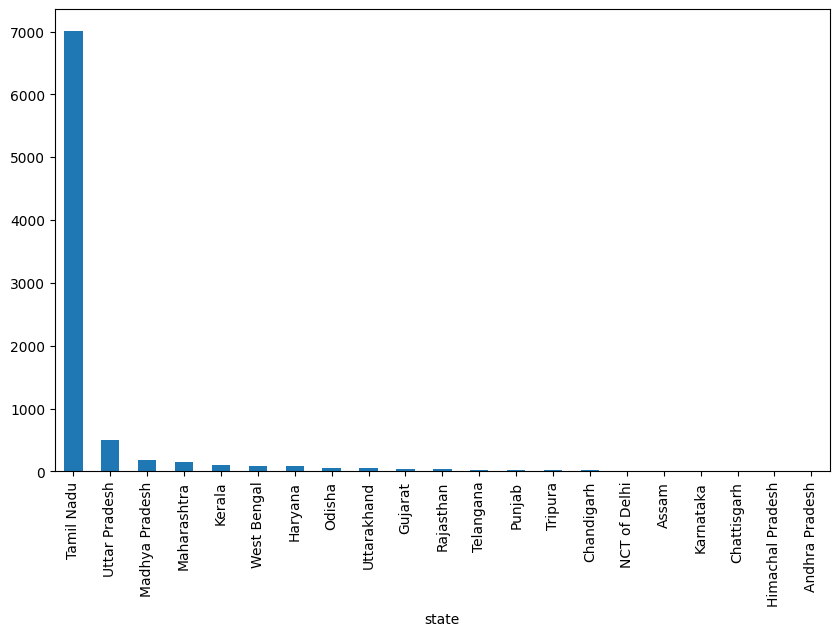

In [84]:
df['state'].value_counts().plot(kind='bar', figsize=(10, 6))